# Spark ML Определение мошеннических транзакций

Источник данных: очищенные данные транзакций, формат - parquet

Описания полей:

 | Название        | Описание                                                                                                                            |
 |:----------------|:--------------------------------------------------------------------|
 | transaction_id       | уникальный идентификатор транзакции|
 | tx_datetime  | время транзакции (timestamp)|
 | customer_id    | уникальный идентификатор клиента (может быть -1)|
 | terminal_id          | уникальный идентификатор терминала (может быть -1)|
 | tx_amount | сумма транзакции|
 | tx_time_seconds | время в секундах от точки отсчёта (может быть -1)|
 | tx_time_days  | Время в днях от точки отсчёта (может быть -1)|
 | tx_fraud | признак мошенничества (bool)|
 | tx_fraud_scenario   | сценарий мошенничества (может быть -1)|
 

In [33]:
import findspark
findspark.init()

In [34]:
from datetime import datetime
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col,
    when,
    to_timestamp,
    lit
)

from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, LongType, TimestampType, BooleanType
from pyspark.sql.window import Window
import math
from functools import reduce
from datetime import datetime

In [35]:
import pyspark
pyspark.__version__

'3.0.3'

In [36]:
if 'spark' in locals() or 'spark' in globals():
    spark.stop()
    

In [37]:
# =====================================================
# Создание сессии
# =====================================================

spark = (
            SparkSession.builder
                .appName("Spark ML Clean Data")
                # 1. Используем все ядра (16), но оставляем 1-2 для системы
                .master("local[14]")
                # 2. Память Драйвера (в локальном режиме это основная настройка)
                # Выделяем 16-20 ГБ, чтобы спокойно делать .toPandas() и обучать модели
                .config("spark.driver.memory", "18g")
                # 3. Лимит на размер объектов, собираемых на драйвере (увеличиваем для тяжелых операций)
                .config("spark.driver.maxResultSize", "8g")
                # 4. Включаем современные оптимизации 2025 года (Adaptive Query Execution)
                .config("spark.sql.adaptive.enabled", "true")
                # 5. Оптимизация работы с памятью при передаче данных в Pandas
                .config("spark.sql.execution.arrow.pyspark.enabled", "false")
                #.config("spark.sql.adaptive.skewJoin.enabled", "true")
                #.config("spark.driver.extraJavaOptions", "--add-opens=java.base/java.nio=ALL-UNNAMED")
                #.config("spark.executor.extraJavaOptions", "--add-opens=java.base/java.nio=ALL-UNNAMED")
                #.config("spark.jars.packages", "com.microsoft.azure:synapseml_2.12:0.11.1") \
                #.config("spark.jars.repositories", "https://mmlspark.azureedge.net") \
                .getOrCreate()
        )

spark.conf.set('spark.sql.repl.eagerEval.enabled', True)  # to pretty print pyspark.DataFrame in jupyter
spark.conf.set("spark.sql.ansi.enabled", "false")

sc = spark.sparkContext
sc.setLogLevel("ERROR")


#logger = spark.sparkContext._jvm.org.apache.log4j.LogManager.getLogger("DataQuality")

class Clogger():
    def warn(self,msg):
        print(msg)
logger = Clogger()

In [38]:
# =====================================================
# Конфигурация
# =====================================================
INPUT_PATH = './in_folder/'
#OUTPUT_PATH = "s3a://your-bucket/clean/transactions_parquet/"
OUTPUT_PATH = "./out_folder"
DATETIME_FORMAT = "yyyy-MM-dd HH:mm:ss"

BAD_VALUE = -1


## EDA

In [39]:
# =====================================================
# Чтение данных
# =====================================================
df = spark.read.parquet (
    INPUT_PATH
)

26/03/24 22:59:17 ERROR Executor: Exception in task 0.0 in stage 0.0 (TID 0)
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:302)
	at org.apache.spark.util.ThreadUtils$.parmap(ThreadUtils.scala:376)
	at org.apache.spark.sql.execution.datasources.parquet.ParquetFileFormat$.readParquetFootersInParallel(ParquetFileFormat.scala:444)
	at org.apache.spark.sql.execution.datasources.parquet.ParquetFileFormat$.$anonfun$mergeSchemasInParallel$1(ParquetFileFormat.scala:490)
	at org.apache.spark.sql.execution.datasources.parquet.ParquetFileFormat$.$anonfun$mergeSchemasInParallel$1$adapted(ParquetFileFormat.scala:484)
	at org.apache.spark.sql.execution.datasources.SchemaMergeUtils$.$anonfun$mergeSchemasInParallel$2(SchemaMergeUtils.scala:75)
	at org.apache.spark.rdd.RDD.$anonfun$mapPartitions$2(RDD.scala:837)
	at org.apache.spark.rdd.RDD.$anonfun$mapPartitions$2$adapted(RDD.scala:837)
	at org.apache.spark.rdd.Ma

Py4JJavaError: An error occurred while calling o326.parquet.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 0 in stage 0.0 failed 1 times, most recent failure: Lost task 0.0 in stage 0.0 (TID 0, 192.168.88.251, executor driver): org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:302)
	at org.apache.spark.util.ThreadUtils$.parmap(ThreadUtils.scala:376)
	at org.apache.spark.sql.execution.datasources.parquet.ParquetFileFormat$.readParquetFootersInParallel(ParquetFileFormat.scala:444)
	at org.apache.spark.sql.execution.datasources.parquet.ParquetFileFormat$.$anonfun$mergeSchemasInParallel$1(ParquetFileFormat.scala:490)
	at org.apache.spark.sql.execution.datasources.parquet.ParquetFileFormat$.$anonfun$mergeSchemasInParallel$1$adapted(ParquetFileFormat.scala:484)
	at org.apache.spark.sql.execution.datasources.SchemaMergeUtils$.$anonfun$mergeSchemasInParallel$2(SchemaMergeUtils.scal

In [48]:
schema = StructType([
    StructField("transaction_id", LongType(), True),
    StructField("tx_datetime", StringType(), True),
    StructField("customer_id", IntegerType(), True),
    StructField("terminal_id", IntegerType(), True),
    StructField("tx_amount", DoubleType(), True),
    StructField("tx_time_seconds", IntegerType(), True),
    StructField("tx_time_days", IntegerType(), True),
    StructField("tx_fraud", IntegerType(), True),
    StructField("tx_fraud_scenario", IntegerType(), True),
    StructField("_corrupt", StringType(), True)
])

df = (
    spark.read
    .option("header", False)
    .option("comment", "#")
    .option("mode", "PERMISSIVE")
    .option("columnNameOfCorruptRecord", "_corrupt")
    .schema(schema)
    .csv(INPUT_PATH)
)

In [49]:
df = df.withColumn("unix_time", F.col("tx_datetime").cast(TimestampType()).cast("long"))
min_date = df.select(F.min("unix_time")).collect()[0][0]
max_date = df.select(F.max("unix_time")).collect()[0][0]
start_training_date = min_date + 3600*24*30+3600

print(f'del: {datetime.fromtimestamp(min_date)} --> {datetime.fromtimestamp(start_training_date)}')
print(f'keep: {datetime.fromtimestamp(start_training_date)} --> {datetime.fromtimestamp(max_date)}')

[Stage 34:======================================================> (62 + 2) / 64]

del: 2019-08-22 00:00:00 --> 2019-09-21 01:00:00
keep: 2019-09-21 01:00:00 --> 2019-11-19 23:59:59


In [25]:
min_date

In [47]:
df.limit(5)

transaction_id,tx_datetime,customer_id,terminal_id,tx_amount,tx_time_seconds,tx_time_days,tx_fraud,tx_fraud_scenario,_corrupt,unix_time
0,2019-08-22 06:51:03,0,711,70.91,24663,0,0,0,null,1566431463
1,2019-08-22 05:10:37,0,0,90.55,18637,0,0,0,null,1566425437
2,2019-08-22 19:05:33,0,753,35.38,68733,0,0,0,null,1566475533
3,2019-08-22 07:21:33,0,0,80.41,26493,0,0,0,null,1566433293
4,2019-08-22 09:06:17,1,981,102.83,32777,0,0,0,null,1566439577


In [ ]:
dt = df.dtypes
for r in dt:
    print(f"{r[0]:>25}\t{r[1]}")

In [ ]:
#понятно, что с данные не сбалансированы
df.groupBy("tx_fraud").count()

In [ ]:
a = df.groupBy("tx_fraud").count()\
    .toPandas()['count'].to_list()
print(f'{a[0]/a[1]*100}% - мошенничеств')

In [ ]:
df.summary()

In [ ]:
df.groupBy("customer_id").count().sort(F.desc("count")).show()

In [ ]:
df.filter(F.col("tx_fraud")==True).groupBy("customer_id").count().sort(F.desc("count")).show()

In [ ]:
df.groupBy("terminal_id").count().sort(F.desc("count")).show()

In [ ]:
df.filter(F.col("tx_fraud")==True).groupBy("terminal_id").count().sort(F.desc("count")).show()

In [ ]:
df.groupBy("customer_id","terminal_id").count().sort(F.desc("count")).show()

In [ ]:
похоже окна по терминалу не очень хорошая идея

In [ ]:
#посмотрим, можно ли полагаться на поле tx_time_seconds и по порядку ли у нас формируются id транзакций
w_prev = Window.partitionBy("customer_id","terminal_id").orderBy("tx_time_seconds","transaction_id")
t_data = df.withColumn("prev_tx_transaction_id", F.lag("transaction_id").over(w_prev)) \
           .withColumn("transaction_id_since_last_tx", F.col("transaction_id") - F.col("prev_tx_transaction_id")) \
           .withColumn("prev_tx_time", F.lag("tx_time_seconds").over(w_prev)) \
           .withColumn("time_since_last_tx", F.col("tx_time_seconds") - F.col("prev_tx_time"))
#tx_time_seconds

In [ ]:
t_data.filter(F.col("time_since_last_tx")<0).count()

In [ ]:
t_data.filter(F.col("transaction_id_since_last_tx")<0).count()

In [ ]:
t_data.filter(F.col("time_since_last_tx")==0).count()

In [ ]:
df.filter(F.col('tx_fraud') == True).groupBy("tx_fraud_scenario").count()

In [ ]:
t = df.filter(F.col('tx_fraud') == True).groupBy("customer_id").agg(
    F.min(F.col("tx_datetime")).alias('min_time'),
    F.max(F.col("tx_datetime")).alias('max_time')
).withColumn("diff_time",F.col("max_time").cast("long")-F.col("min_time").cast("long"))

In [ ]:
t.agg({"diff_time": "max"}).collect()[0][0] // (3600*24)

In [ ]:
сохраняем для дальнейшего анализа по паре пользователей и терминалов по всем типам фрода

In [ ]:
tmp_df = df.filter( (F.col('customer_id').isin([732577,741839,921532,945365,141515,472986 ]) )
           | (F.col('terminal_id').isin([522,716,507,240,99,666]) )
         )
print(tmp_df .count())
tmp_df.repartition(1).write.mode("overwrite").parquet('./tmp')

In [ ]:
Датасет отсортирован по id транзакции, при этом время транзакции как и поле tx_time_seconds 
получается отсортированным неправильно
проверка предположения, что время зависит от клиента и/или терминала связи не выявило
предположим, что id присваивается не совсем по порядку и будем ориентироваться больше на время, 
из времени можно получить достаточно много признаков

In [ ]:
Учитывая то, что в нашем датасете кроме суммы транзакции подходящих признаков для модели в общем то и нет, 
придётся формировать признаки почти что с нуля. 
Однако для начала попробуем с помощью randomforest всё таки предстказать

## Генерация признаков

In [7]:
import re

def interval_to_seconds(interval_str):
    """Превращает '1 minute', '2 hours', '10s' в секунды (int)."""
    units = {
        "s": 1, "second": 1, "seconds": 1,
        "m": 60, "minute": 60, "minutes": 60,
        "h": 3600, "hour": 3600, "hours": 3600,
        "d": 86400, "day": 86400, "days": 86400
    }
    match = re.match(r"(\d+)\s*([a-zA-Z]+)", interval_str.lower().strip())
    if match:
        value, unit = match.groups()
        return int(value) * units.get(unit, 0)
    return None

def create_windows(partition_col, time_col, window_definitions, prefix_name='tx'):
    """
    window_definitions: dict вида {"название": (start_sec, end_sec)}
    Пример: {"1d_hist": (-86400, -1), "1d_full": (-86399, 0)}
    """
    windows = {}
    for name, (start, end) in window_definitions.items():
        windows[f'{prefix_name}_{name}'] = Window.partitionBy(*partition_col) \
                              .orderBy(time_col) \
                              .rangeBetween(start, end)
    print(',\n'.join(windows.keys()))
    return windows


def add_aggregated_features(df, target_col, windows, agg_types=["count", "avg"],prefix=''):
    """
    df: DataFrame
    target_col: колонка для агрегации (напр. 'TX_AMOUNT')
    windows: словарь объектов WindowSpec из create_windows
    agg_types: типы агрегатов
    isnew_col работает, когда окно до текущей транзакции не включая её
    """
    for win_name, win_spec in windows.items():
        # Базовые агрегаты
        if "count" in agg_types or "avg" in agg_types or "isnew" in agg_types:
            count_col = f"{prefix}{target_col}_cn_{win_name}"
            df = df.withColumn(count_col, F.count(target_col).over(win_spec))
        
        if "sum" in agg_types or "avg" in agg_types:
            sum_col = f"{prefix}temp_sum_{win_name}"
            df = df.withColumn(sum_col, F.sum(target_col).over(win_spec))
            
            if "avg" in agg_types:
                # В Spark avg через Window может быть медленнее, чем sum/count,
                # но при наличии count это просто деление
                df = df.withColumn(f"{prefix}{target_col}_avg_{win_name}", F.col(sum_col) / F.col(count_col))
            
            if "sum" not in agg_types:
                df = df.drop(sum_col)
                
        if "std" in agg_types:
             df = df.withColumn(f"{target_col}_std_{win_name}", F.stddev(F.col(target_col)).over(win_spec))

        if "isnew" in agg_types:
            isnew_col = f"{prefix}{target_col}_isnew_{win_name}"
            df = df.withColumn(isnew_col, F.when(F.col(count_col) == 0, 1).otherwise(0))

        if "count" not in agg_types and ("avg" in agg_types or "isnew" in agg_types):
            df = df.drop(count_col)
              
    return df

def add_ratio_features(df, target_col, windows, agg_types="avg"):
    """
    df: DataFrame
    target_col: колонка текущего значения (напр. 'TX_AMOUNT')
    windows: словарь объектов WindowSpec (ВАЖНО: здесь лучше использовать окна с -1)
    agg_type: тип исторического агрегата для сравнения ('avg', 'sum', 'max')
    """
    prefix='T__prefix__'
    cols = df.columns
    #print(cols)
    df = add_aggregated_features(df, target_col, windows, agg_types=agg_types,
                                 prefix=prefix)
    #print(df.columns)
    hist_agg_cols = [cl for cl in df.columns if not cl in cols]
    #print(hist_agg_cols)
    for col_name in hist_agg_cols:
        ratio_col_name = f"ratio_{col_name.replace(prefix,'')}"
    
        # Используем coalesce, чтобы избежать деления на NULL или 0
        # Если истории нет, рейт обычно принимается равным 1.0 (норма)
        df = df.withColumn(
            ratio_col_name, 
            F.col(target_col) / F.when(F.col(col_name) != 0, F.col(col_name)).otherwise(F.col(target_col))
        )
    
    # Удаляем промежуточную колонку с агрегатом, чтобы не замусоривать датасет
    df = df.drop(*hist_agg_cols)
        
    return df



def add_ratio_features_simple(df, target_col, hist_agg_cols,drop_hist=False):


    for col_name in hist_agg_cols:
        ratio_col_name = f"ratio_{col_name}"
    
        # Используем coalesce, чтобы избежать деления на NULL или 0
        # Если истории нет, рейт обычно принимается равным 1.0 (норма)
        df = df.withColumn(
            ratio_col_name, 
            F.col(target_col) / F.when(F.col(col_name) != 0, F.col(col_name)).otherwise(F.col(target_col))
        )
    
    # Удаляем промежуточную колонку с агрегатом, чтобы не замусоривать датасет
    if drop_hist:
        df = df.drop(*hist_agg_cols)
        
    return df
    

def add_aggregated_features_for_heavy(df, partition_cols, time_col, target_col, 
                                      windows_definitions, 
                                      bucket_interval=60,
                                      agg_types=['count'],
                                      include_current=True,
                                      end_of_current=0,
                                      prefix = ""
                                      ):
    """
    Расчет агрегатов (AVG, STD, COUNT) с учетом текущей транзакции 
    без перекоса данных.
    для включения в результат текущих значений все окна должны оканчиваться одинаково на -bucket_interval
    """
    
    need_count = "count" in agg_types
    need_sum = "sum" in agg_types
    need_avg = "avg" in agg_types
    need_std = "std" in agg_types

    # 1. СТАДИЯ "СЖАТИЯ" (Stage 1: Bucket Aggregation)
    # Создаем временные бакеты
    #df_with_buckets = df.withColumn(
    #"_bucket", 
    #F.window(F.col(time_col), bucket_interval)["start"].cast("long")
    #)
    df_with_buckets = df.withColumn(
        "_bucket", 
        (F.col(time_col) / bucket_interval).cast("long") * bucket_interval
    )
    
    agg_ops = []

    if need_count or need_avg:
        agg_ops.append(F.count(target_col).alias("_b_cnt"))
    
    if need_sum or need_avg:
        agg_ops.append(F.sum(target_col).alias("_b_sum"))
            
    if need_std:
        agg_ops.append(F.sum(F.col(target_col)**2).alias("_b_sum_sq"))
    
    
    # Агрегируем компоненты для сумм, средних и стандартного отклонения
    df_buckets = df_with_buckets.groupBy(*partition_cols, "_bucket").agg(
        *agg_ops
    )
    
    # 2. СТАДИЯ "ИСТОРИИ" (Stage 2: Sliding Windows on Buckets)
    # Рассчитываем агрегаты только по ПРОШЛЫМ бакетам (не включая текущий)

    # 2. СТАДИЯ "ИСТОРИИ"
    # ВАЖНО: Пересоздаем окна специально для df_buckets по колонке _bucket
    for win_name, (start, end) in windows_definitions.items():
        # Создаем новое окно для агрегации бакетов
        win_spec = Window.partitionBy(*partition_cols).orderBy("_bucket").rangeBetween(start, end)
        
        if need_count or need_avg:
            count_col = f"{prefix}_{target_col}_cn_{win_name}"
            df_buckets = df_buckets.withColumn(count_col+"_hist", F.sum("_b_cnt").over(win_spec))
        if need_sum or need_avg:
            sum_col = f"{prefix}_{target_col}_sum_{win_name}"
            df_buckets = df_buckets.withColumn(sum_col+"_hist", F.sum("_b_sum").over(win_spec))
        if need_std:
            sum_sq_col = f"{prefix}_{target_col}_sum_sq_{win_name}"
            df_buckets = df_buckets.withColumn(sum_sq_col+"_hist", F.sum("_b_sum_sq").over(win_spec))

    # 3. Соединение и инкремент (Stage 3)
    df_final = df_with_buckets.join(df_buckets.drop("_b_sum", "_b_cnt", "_b_sum_sq"), 
                                    on=[*partition_cols, "_bucket"], how="left")
    

    if include_current:
        win_local = Window.partitionBy(*partition_cols, "_bucket").orderBy(time_col) \
                          .rangeBetween(Window.unboundedPreceding, end_of_current)
        
        if need_count or need_avg or need_std:
            curr_cnt = F.count(target_col).over(win_local)
        if need_sum or need_avg:
            curr_sum = F.sum(target_col).over(win_local)
        if need_std:
            curr_sum_sq = F.sum(F.col(target_col)**2).over(win_local)
    else:
        # Если текущий не нужен, инкремент равен нулю
        curr_sum = curr_cnt = curr_sum_sq = F.lit(0)

    
    
     # 4. ФИНАЛЬНЫЙ РАСЧЕТ И ОБРАБОТКА NULL (Stage 4: Fusion & Cleaning)
    drop_list = ["_bucket"]
    for win_name in windows_definitions.keys():
        # Берем историю из Join (если ее нет — 0)
        if need_count or need_avg or need_std:
            count_col = f"{prefix}_{target_col}_cn_{win_name}"
            h_cnt = F.coalesce(F.col(count_col+"_hist"), F.lit(0))
            curr_sum = F.coalesce(curr_sum,F.lit(0))
            total_cnt = h_cnt + curr_cnt
            drop_list.append(count_col+"_hist")
        if need_sum or need_avg:
            sum_col = f"{prefix}_{target_col}_sum_{win_name}"
            h_sum = F.coalesce(F.col(sum_col+"_hist"), F.lit(0))
            curr_cnt = F.coalesce(curr_cnt,F.lit(0))
            total_sum = h_sum + curr_sum
            drop_list.append(sum_col+"_hist")
        if need_std:
            sum_sq_col = f"{prefix}_{target_col}_sum_sq_{win_name}"
            h_sum_sq = F.coalesce(F.col(sum_sq_col+"_hist"), F.lit(0))
            curr_sum_sq = F.coalesce(curr_sum_sq,F.lit(0))
            total_sum_sq = h_sum_sq + curr_sum_sq
            
            std_col_name = f"{prefix}_{target_col}_std_{win_name}"
            variance = (total_sum_sq / total_cnt) - ( (total_sum / total_cnt)**2 )
            df_final = df_final.withColumn(std_col_name,
                        F.when(total_cnt > 1, F.sqrt(F.greatest(F.lit(0), variance))).otherwise(F.lit(0)))
            
            drop_list.append(sum_sq_col+"_hist")

   
        # Базовые агрегаты
        if need_count:
            df_final = df_final.withColumn(count_col, total_cnt)
        if need_sum:
            df_final = df_final.withColumn(sum_col, total_sum)
        if need_avg:
            avg_col_name = f"{prefix}_{target_col}_avg_{win_name}"
            df_final = df_final.withColumn(avg_col_name,
                        F.when(total_cnt > 0, total_sum / total_cnt).otherwise(F.col(target_col)))

    # Финальная чистка технических колонок
    df_final = df_final.drop(*drop_list)
    #print(drop_list)
    return df_final

def get_count_risk_rolling_window_spark(df,full_colls, delay_cols,del_in_cols = True):

    col_delay_sum = [col for col in delay_cols if "_sum_" in col][0]
    col_delay_cn = [col for col in delay_cols if "_cn_" in col][0]

    drop_list = []
    for sum_col_name,cn_col_name in full_colls:
       
        # Вычитаем задержку, чтобы получить чистое окно в прошлом
        nb_fraud_window = F.col(sum_col_name) - F.col(col_delay_sum)
        nb_tx_window = F.col(cn_col_name) - F.col(col_delay_cn)
        
        # Считаем риск (используем nullif во избежание деления на ноль)
        risk_window = nb_fraud_window / F.when(nb_tx_window == 0, None).otherwise(nb_tx_window)
        
        # Добавляем колонки
        df = df.withColumn(f"{cn_col_name}_delay", F.coalesce(nb_tx_window, F.lit(0))) \
               .withColumn(f"{sum_col_name.replace('_sum_','_risk_')}_delay", F.coalesce(risk_window, F.lit(0.0)))

        drop_list.append(sum_col_name)
        drop_list.append(cn_col_name)
        
    drop_list.append(col_delay_sum)
    drop_list.append(col_delay_cn)

    if del_in_cols:
        df = df.drop(*drop_list)
    
    return df
    

In [9]:
HOUR = 3600
DAY = 24 * 3600
WEEK = 7 * 24 * 3600
TMIN = 1*60

In [10]:
features_df = df.withColumn("unix_time", F.col("TX_DATETIME").cast("long"))
features_df = features_df.withColumn("tx_fraud", col("tx_fraud").cast(IntegerType()))
features_df.columns

['transaction_id',
 'tx_datetime',
 'customer_id',
 'terminal_id',
 'tx_amount',
 'tx_time_seconds',
 'tx_time_days',
 'tx_fraud',
 'tx_fraud_scenario',
 'unix_time']

In [11]:
# Определяем временные границы для "прогрева" признаков
# Дата самой первой транзакции, чтобы отсчитать от нее 7 дней
min_date = features_df.select(F.min("unix_time")).collect()[0][0]
max_date = features_df.select(F.max("unix_time")).collect()[0][0]
start_training_date = min_date + 3600*24*7+3600
print('del:')
print(datetime.fromtimestamp(min_date),' --> ',datetime.fromtimestamp(start_training_date))
print('keep:')
print(datetime.fromtimestamp(start_training_date),' --> ',datetime.fromtimestamp(max_date))

del:
2022-11-04 00:00:00  -->  2022-11-11 01:00:00
keep:
2022-11-11 01:00:00  -->  2022-12-03 23:59:59


In [12]:
#определяем основные окна
TIME_COL = "unix_time"

ct_win_defs = {"7d_hist": (-WEEK-1, -1)}

win_defs_current = {
            "7d_full": (-WEEK, 0),
            "1d_full": (-DAY, 0),
            "1h_full": (-HOUR, 0),
          }


win_defs_hist = {
            "7d_hist": (-WEEK-HOUR, -HOUR),
            "1d_hist": (-DAY-HOUR, -HOUR),
          }


win_ct = create_windows(["customer_id","terminal_id"], TIME_COL, ct_win_defs, 
                          prefix_name = 'ct')


win_cust_current = create_windows(["customer_id"], TIME_COL, win_defs_current, 
                          prefix_name = 'cust')

win_cust_hist = create_windows(["customer_id"], TIME_COL, win_defs_hist, 
                          prefix_name = 'cust')


win_term_current = create_windows(["terminal_id"], TIME_COL, win_defs_current, 
                          prefix_name = 'term')

win_term_hist = create_windows(["terminal_id"], TIME_COL, win_defs_hist, 
                          prefix_name = 'term')

ct_7d_hist
cust_7d_full,
cust_1d_full,
cust_1h_full
cust_7d_hist,
cust_1d_hist
term_7d_full,
term_1d_full,
term_1h_full
term_7d_hist,
term_1d_hist


In [13]:
# Был ли пользователь на этом терминале хоть раз за 30 дней
features_df = add_aggregated_features(features_df,'tx_amount', 
                                      win_ct, agg_types=["isnew"])
features_df.columns

['transaction_id',
 'tx_datetime',
 'customer_id',
 'terminal_id',
 'tx_amount',
 'tx_time_seconds',
 'tx_time_days',
 'tx_fraud',
 'tx_fraud_scenario',
 'unix_time',
 'tx_amount_isnew_ct_7d_hist']

In [14]:
#статистики по пользователю с текущими значениями
features_df = add_aggregated_features(features_df,'tx_amount', win_cust_current, agg_types=["count", "avg"])
features_df.columns

['transaction_id',
 'tx_datetime',
 'customer_id',
 'terminal_id',
 'tx_amount',
 'tx_time_seconds',
 'tx_time_days',
 'tx_fraud',
 'tx_fraud_scenario',
 'unix_time',
 'tx_amount_isnew_ct_7d_hist',
 'tx_amount_cn_cust_7d_full',
 'tx_amount_avg_cust_7d_full',
 'tx_amount_cn_cust_1d_full',
 'tx_amount_avg_cust_1d_full',
 'tx_amount_cn_cust_1h_full',
 'tx_amount_avg_cust_1h_full']

In [15]:
#add ratio customer history
features_df = add_aggregated_features(features_df,'tx_amount', win_cust_hist, agg_types=["avg","std",'count'])
features_df.columns

['transaction_id',
 'tx_datetime',
 'customer_id',
 'terminal_id',
 'tx_amount',
 'tx_time_seconds',
 'tx_time_days',
 'tx_fraud',
 'tx_fraud_scenario',
 'unix_time',
 'tx_amount_isnew_ct_7d_hist',
 'tx_amount_cn_cust_7d_full',
 'tx_amount_avg_cust_7d_full',
 'tx_amount_cn_cust_1d_full',
 'tx_amount_avg_cust_1d_full',
 'tx_amount_cn_cust_1h_full',
 'tx_amount_avg_cust_1h_full',
 'tx_amount_cn_cust_7d_hist',
 'tx_amount_avg_cust_7d_hist',
 'tx_amount_std_cust_7d_hist',
 'tx_amount_cn_cust_1d_hist',
 'tx_amount_avg_cust_1d_hist',
 'tx_amount_std_cust_1d_hist']

In [16]:
#статистики по терминалу исторические + текущие
features_df = add_aggregated_features_for_heavy(features_df, ['terminal_id'], TIME_COL, 'tx_amount', 
                                      win_defs_current, 
                                      bucket_interval=3600, 
                                      agg_types=["avg","count"],
                                      include_current=True,
                                      end_of_current=0,
                                      prefix='term')
features_df.columns

['terminal_id',
 'transaction_id',
 'tx_datetime',
 'customer_id',
 'tx_amount',
 'tx_time_seconds',
 'tx_time_days',
 'tx_fraud',
 'tx_fraud_scenario',
 'unix_time',
 'tx_amount_isnew_ct_7d_hist',
 'tx_amount_cn_cust_7d_full',
 'tx_amount_avg_cust_7d_full',
 'tx_amount_cn_cust_1d_full',
 'tx_amount_avg_cust_1d_full',
 'tx_amount_cn_cust_1h_full',
 'tx_amount_avg_cust_1h_full',
 'tx_amount_cn_cust_7d_hist',
 'tx_amount_avg_cust_7d_hist',
 'tx_amount_std_cust_7d_hist',
 'tx_amount_cn_cust_1d_hist',
 'tx_amount_avg_cust_1d_hist',
 'tx_amount_std_cust_1d_hist',
 'term_tx_amount_cn_7d_full',
 'term_tx_amount_avg_7d_full',
 'term_tx_amount_cn_1d_full',
 'term_tx_amount_avg_1d_full',
 'term_tx_amount_cn_1h_full',
 'term_tx_amount_avg_1h_full']

In [17]:
#статистики по терминалу исторические
#features_df = add_aggregated_features(features_df,'tx_amount', win_term_current, agg_types=["count", "avg","std"])

features_df = add_aggregated_features_for_heavy(features_df, ['terminal_id'], TIME_COL, 'tx_amount', 
                                      win_defs_hist, 
                                      bucket_interval=3600, 
                                      agg_types=["avg","count",'std'],
                                      include_current=False,
                                      end_of_current=0,
                                      prefix='term')
features_df.columns

['terminal_id',
 'transaction_id',
 'tx_datetime',
 'customer_id',
 'tx_amount',
 'tx_time_seconds',
 'tx_time_days',
 'tx_fraud',
 'tx_fraud_scenario',
 'unix_time',
 'tx_amount_isnew_ct_7d_hist',
 'tx_amount_cn_cust_7d_full',
 'tx_amount_avg_cust_7d_full',
 'tx_amount_cn_cust_1d_full',
 'tx_amount_avg_cust_1d_full',
 'tx_amount_cn_cust_1h_full',
 'tx_amount_avg_cust_1h_full',
 'tx_amount_cn_cust_7d_hist',
 'tx_amount_avg_cust_7d_hist',
 'tx_amount_std_cust_7d_hist',
 'tx_amount_cn_cust_1d_hist',
 'tx_amount_avg_cust_1d_hist',
 'tx_amount_std_cust_1d_hist',
 'term_tx_amount_cn_7d_full',
 'term_tx_amount_avg_7d_full',
 'term_tx_amount_cn_1d_full',
 'term_tx_amount_avg_1d_full',
 'term_tx_amount_cn_1h_full',
 'term_tx_amount_avg_1h_full',
 'term_tx_amount_std_7d_hist',
 'term_tx_amount_cn_7d_hist',
 'term_tx_amount_avg_7d_hist',
 'term_tx_amount_std_1d_hist',
 'term_tx_amount_cn_1d_hist',
 'term_tx_amount_avg_1d_hist']

In [18]:
#подсчёт новых пользователей на терминале
#features_df = add_aggregated_features(features_df,'tx_amount_isnew_ct_30d_hist',
#                                       {'term_7d_hist': win_term_hist['term_7d_hist']} | win_term_current
#                                      , agg_types=["count"])

features_df = add_aggregated_features_for_heavy(features_df, ['terminal_id'], TIME_COL, 'tx_amount_isnew_ct_7d_hist', 
                                      win_defs_current,
                                      bucket_interval=3600, 
                                      agg_types=["sum"],
                                      include_current=False,
                                      end_of_current=0,
                                      prefix='term')
features_df.columns

['terminal_id',
 'transaction_id',
 'tx_datetime',
 'customer_id',
 'tx_amount',
 'tx_time_seconds',
 'tx_time_days',
 'tx_fraud',
 'tx_fraud_scenario',
 'unix_time',
 'tx_amount_isnew_ct_7d_hist',
 'tx_amount_cn_cust_7d_full',
 'tx_amount_avg_cust_7d_full',
 'tx_amount_cn_cust_1d_full',
 'tx_amount_avg_cust_1d_full',
 'tx_amount_cn_cust_1h_full',
 'tx_amount_avg_cust_1h_full',
 'tx_amount_cn_cust_7d_hist',
 'tx_amount_avg_cust_7d_hist',
 'tx_amount_std_cust_7d_hist',
 'tx_amount_cn_cust_1d_hist',
 'tx_amount_avg_cust_1d_hist',
 'tx_amount_std_cust_1d_hist',
 'term_tx_amount_cn_7d_full',
 'term_tx_amount_avg_7d_full',
 'term_tx_amount_cn_1d_full',
 'term_tx_amount_avg_1d_full',
 'term_tx_amount_cn_1h_full',
 'term_tx_amount_avg_1h_full',
 'term_tx_amount_std_7d_hist',
 'term_tx_amount_cn_7d_hist',
 'term_tx_amount_avg_7d_hist',
 'term_tx_amount_std_1d_hist',
 'term_tx_amount_cn_1d_hist',
 'term_tx_amount_avg_1d_hist',
 'term_tx_amount_isnew_ct_7d_hist_sum_7d_full',
 'term_tx_amount_isn

In [19]:
#подсчёт риска терминала
win_delay_fraud  = {
            "3d_delay": (-DAY*3, 0)
          }

win_fraud  = {
            "1d_full": (-DAY-DAY*3, 0),
            "4d_full": (-DAY*4-DAY*3, 0)
          }

#получаем базовое окно задержки для вычитания
features_df = add_aggregated_features_for_heavy(features_df, ['terminal_id'], TIME_COL, 'tx_fraud', 
                                      win_delay_fraud,
                                      bucket_interval=3600, 
                                      agg_types=["sum","count"],
                                      include_current=False,
                                      end_of_current=0,
                                      prefix='fraud')
features_df.columns

['terminal_id',
 'transaction_id',
 'tx_datetime',
 'customer_id',
 'tx_amount',
 'tx_time_seconds',
 'tx_time_days',
 'tx_fraud',
 'tx_fraud_scenario',
 'unix_time',
 'tx_amount_isnew_ct_7d_hist',
 'tx_amount_cn_cust_7d_full',
 'tx_amount_avg_cust_7d_full',
 'tx_amount_cn_cust_1d_full',
 'tx_amount_avg_cust_1d_full',
 'tx_amount_cn_cust_1h_full',
 'tx_amount_avg_cust_1h_full',
 'tx_amount_cn_cust_7d_hist',
 'tx_amount_avg_cust_7d_hist',
 'tx_amount_std_cust_7d_hist',
 'tx_amount_cn_cust_1d_hist',
 'tx_amount_avg_cust_1d_hist',
 'tx_amount_std_cust_1d_hist',
 'term_tx_amount_cn_7d_full',
 'term_tx_amount_avg_7d_full',
 'term_tx_amount_cn_1d_full',
 'term_tx_amount_avg_1d_full',
 'term_tx_amount_cn_1h_full',
 'term_tx_amount_avg_1h_full',
 'term_tx_amount_std_7d_hist',
 'term_tx_amount_cn_7d_hist',
 'term_tx_amount_avg_7d_hist',
 'term_tx_amount_std_1d_hist',
 'term_tx_amount_cn_1d_hist',
 'term_tx_amount_avg_1d_hist',
 'term_tx_amount_isnew_ct_7d_hist_sum_7d_full',
 'term_tx_amount_isn

In [20]:
#считаем полные окна с задержкой 
features_df = add_aggregated_features_for_heavy(features_df, ['terminal_id'], TIME_COL, 'tx_fraud', 
                                      win_fraud,
                                      bucket_interval=3600, 
                                      agg_types=["sum","count"],
                                      include_current=False,
                                      end_of_current=0,
                                      prefix='fraud')
features_df.columns

['terminal_id',
 'transaction_id',
 'tx_datetime',
 'customer_id',
 'tx_amount',
 'tx_time_seconds',
 'tx_time_days',
 'tx_fraud',
 'tx_fraud_scenario',
 'unix_time',
 'tx_amount_isnew_ct_7d_hist',
 'tx_amount_cn_cust_7d_full',
 'tx_amount_avg_cust_7d_full',
 'tx_amount_cn_cust_1d_full',
 'tx_amount_avg_cust_1d_full',
 'tx_amount_cn_cust_1h_full',
 'tx_amount_avg_cust_1h_full',
 'tx_amount_cn_cust_7d_hist',
 'tx_amount_avg_cust_7d_hist',
 'tx_amount_std_cust_7d_hist',
 'tx_amount_cn_cust_1d_hist',
 'tx_amount_avg_cust_1d_hist',
 'tx_amount_std_cust_1d_hist',
 'term_tx_amount_cn_7d_full',
 'term_tx_amount_avg_7d_full',
 'term_tx_amount_cn_1d_full',
 'term_tx_amount_avg_1d_full',
 'term_tx_amount_cn_1h_full',
 'term_tx_amount_avg_1h_full',
 'term_tx_amount_std_7d_hist',
 'term_tx_amount_cn_7d_hist',
 'term_tx_amount_avg_7d_hist',
 'term_tx_amount_std_1d_hist',
 'term_tx_amount_cn_1d_hist',
 'term_tx_amount_avg_1d_hist',
 'term_tx_amount_isnew_ct_7d_hist_sum_7d_full',
 'term_tx_amount_isn

In [21]:
#считаем риск удаляем промежуточные поля
features_df = get_count_risk_rolling_window_spark(features_df,
                                                [('fraud_tx_fraud_sum_1d_full','fraud_tx_fraud_cn_1d_full'),
                                                 ('fraud_tx_fraud_sum_4d_full','fraud_tx_fraud_cn_4d_full')], 
                                                ['fraud_tx_fraud_cn_3d_delay',
                                                'fraud_tx_fraud_sum_3d_delay'],
                                                  del_in_cols = True)

In [22]:
features_df.columns

['terminal_id',
 'transaction_id',
 'tx_datetime',
 'customer_id',
 'tx_amount',
 'tx_time_seconds',
 'tx_time_days',
 'tx_fraud',
 'tx_fraud_scenario',
 'unix_time',
 'tx_amount_isnew_ct_7d_hist',
 'tx_amount_cn_cust_7d_full',
 'tx_amount_avg_cust_7d_full',
 'tx_amount_cn_cust_1d_full',
 'tx_amount_avg_cust_1d_full',
 'tx_amount_cn_cust_1h_full',
 'tx_amount_avg_cust_1h_full',
 'tx_amount_cn_cust_7d_hist',
 'tx_amount_avg_cust_7d_hist',
 'tx_amount_std_cust_7d_hist',
 'tx_amount_cn_cust_1d_hist',
 'tx_amount_avg_cust_1d_hist',
 'tx_amount_std_cust_1d_hist',
 'term_tx_amount_cn_7d_full',
 'term_tx_amount_avg_7d_full',
 'term_tx_amount_cn_1d_full',
 'term_tx_amount_avg_1d_full',
 'term_tx_amount_cn_1h_full',
 'term_tx_amount_avg_1h_full',
 'term_tx_amount_std_7d_hist',
 'term_tx_amount_cn_7d_hist',
 'term_tx_amount_avg_7d_hist',
 'term_tx_amount_std_1d_hist',
 'term_tx_amount_cn_1d_hist',
 'term_tx_amount_avg_1d_hist',
 'term_tx_amount_isnew_ct_7d_hist_sum_7d_full',
 'term_tx_amount_isn

In [24]:
# Убираем первую неделю, чтобы убрать записи, где признаки не успели накопиться
features_df = features_df.filter(F.col("unix_time") >= start_training_date)

In [25]:
features_df.write.mode("overwrite").parquet(OUTPUT_PATH)

## Обучение

In [8]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.feature import StandardScaler, PCA

import mlflow
from mlflow.tracking import MlflowClient
import os

import tempfile
import shutil

In [9]:
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net"
TRACKING_SERVER_HOST = "127.0.0.1"
mlflow.set_tracking_uri(f"http://{TRACKING_SERVER_HOST}:5005")

In [10]:
df = spark.read.parquet (
    OUTPUT_PATH
)
df = df.withColumn("tx_fraud", col("tx_fraud").cast(IntegerType()))

In [11]:
PI = math.pi
# Генерация признаков непосредственно из полей записи
df = df \
    .withColumn("hour", F.hour("tx_datetime")) \
    .withColumn("is_night", F.when((F.col("hour") >= 0) & (F.col("hour") < 6), 1).otherwise(0)) \
    .withColumn("day_of_week", F.dayofweek("tx_datetime")) \
    .withColumn("is_weekend", F.when(F.col("day_of_week").isin(1, 7), 1).otherwise(0)) \
    .withColumn("is_rovn_sum", ((F.col("tx_amount") % 100 == 0) | (F.col("tx_amount") % 1000 == 0)).cast("int")) \
    .withColumn("is_unknonw_terminal", (F.col("terminal_id") == -1).cast("int")) \
    .withColumn("is_unknonw_customer", (F.col("customer_id") == -1).cast("int")) \
    .withColumn("hour_sin", F.sin(2 * PI * F.col("hour") / 24)) \
    .withColumn("hour_cos", F.cos(2 * PI * F.col("hour") / 24)) \
    .withColumn("day_sin", F.sin(2 * PI * F.col("day_of_week") / 7)) \
    .withColumn("day_cos", F.cos(2 * PI * F.col("day_of_week") / 7))  

In [12]:
df.columns

['terminal_id',
 'transaction_id',
 'tx_datetime',
 'customer_id',
 'tx_amount',
 'tx_time_seconds',
 'tx_time_days',
 'tx_fraud',
 'tx_fraud_scenario',
 'unix_time',
 'tx_amount_isnew_ct_30d_hist',
 'tx_amount_isnew_ct_7d_hist',
 'tx_amount_cn_cust_7d_full',
 'tx_amount_avg_cust_7d_full',
 'tx_amount_cn_cust_1d_full',
 'tx_amount_avg_cust_1d_full',
 'tx_amount_cn_cust_1h_full',
 'tx_amount_avg_cust_1h_full',
 'tx_amount_cn_cust_30d_hist',
 'tx_amount_avg_cust_30d_hist',
 'tx_amount_std_cust_30d_hist',
 'tx_amount_cn_cust_7d_hist',
 'tx_amount_avg_cust_7d_hist',
 'tx_amount_std_cust_7d_hist',
 'tx_amount_cn_cust_1d_hist',
 'tx_amount_avg_cust_1d_hist',
 'tx_amount_std_cust_1d_hist',
 'term_tx_amount_cn_7d_full',
 'term_tx_amount_avg_7d_full',
 'term_tx_amount_cn_1d_full',
 'term_tx_amount_avg_1d_full',
 'term_tx_amount_cn_1h_full',
 'term_tx_amount_avg_1h_full',
 'term_tx_amount_std_30d_hist',
 'term_tx_amount_cn_30d_hist',
 'term_tx_amount_avg_30d_hist',
 'term_tx_amount_std_7d_hist',

In [13]:
rate_cols = ["term_tx_amount_avg_7d_hist","term_tx_amount_avg_1d_hist",
             "term_tx_amount_std_7d_hist","term_tx_amount_std_1d_hist",
             'tx_amount_avg_cust_7d_hist','tx_amount_std_cust_7d_hist',
             'tx_amount_avg_cust_1d_hist','tx_amount_std_cust_1d_hist']

rate_cols = ["term_tx_amount_avg_30d_hist","term_tx_amount_avg_7d_hist",
             "term_tx_amount_std_30d_hist","term_tx_amount_std_7d_hist",
             'tx_amount_avg_cust_30d_hist','tx_amount_std_cust_30d_hist',
             'tx_amount_avg_cust_7d_hist','tx_amount_std_cust_7d_hist']

df = add_ratio_features_simple(df, "tx_amount", rate_cols,drop_hist=False)

In [14]:
df = df.fillna(0)

In [15]:
df.columns

['terminal_id',
 'transaction_id',
 'tx_datetime',
 'customer_id',
 'tx_amount',
 'tx_time_seconds',
 'tx_time_days',
 'tx_fraud',
 'tx_fraud_scenario',
 'unix_time',
 'tx_amount_isnew_ct_30d_hist',
 'tx_amount_isnew_ct_7d_hist',
 'tx_amount_cn_cust_7d_full',
 'tx_amount_avg_cust_7d_full',
 'tx_amount_cn_cust_1d_full',
 'tx_amount_avg_cust_1d_full',
 'tx_amount_cn_cust_1h_full',
 'tx_amount_avg_cust_1h_full',
 'tx_amount_cn_cust_30d_hist',
 'tx_amount_avg_cust_30d_hist',
 'tx_amount_std_cust_30d_hist',
 'tx_amount_cn_cust_7d_hist',
 'tx_amount_avg_cust_7d_hist',
 'tx_amount_std_cust_7d_hist',
 'tx_amount_cn_cust_1d_hist',
 'tx_amount_avg_cust_1d_hist',
 'tx_amount_std_cust_1d_hist',
 'term_tx_amount_cn_7d_full',
 'term_tx_amount_avg_7d_full',
 'term_tx_amount_cn_1d_full',
 'term_tx_amount_avg_1d_full',
 'term_tx_amount_cn_1h_full',
 'term_tx_amount_avg_1h_full',
 'term_tx_amount_std_30d_hist',
 'term_tx_amount_cn_30d_hist',
 'term_tx_amount_avg_30d_hist',
 'term_tx_amount_std_7d_hist',

In [18]:
# Prepare MLFlow experiment for logging

client = MlflowClient()
experiment_name = f"Anti-Fraud-System2"
experiment = client.get_experiment_by_name(experiment_name)
if experiment:
    experiment_id = experiment.experiment_id
else:
    experiment = client.create_experiment(experiment_name)
    experiment_id = experiment.experiment_id

In [19]:
experiment_id

'3'

In [20]:
def split_train_test_by_time(df, train_ratio=0.8, time_col='tx_datetime'):
    """
    Разделяет датасет на train/test по времени без перемешивания.
    """
    # 1. Находим минимальное и максимальное время (в секундах для точности)
    # Или используем tx_time_seconds, если он заполнен и корректен
    stats = df.select(
        F.min(time_col).alias('min_t'),
        F.max(time_col).alias('max_t')
    ).collect()[0]
    
    start_t = stats['min_t']
    end_t = stats['max_t']
    
    # 2. Вычисляем точку отсечения (threshold) через перцентиль
    # approxQuantile работает быстрее на больших объемах, чем точная сортировка
    threshold = df.stat.approxQuantile(time_col, [train_ratio], 0.01)[0]
    
    # 3. Разделяем данные
    train_df = df.filter(F.col(time_col) <= threshold)
    test_df = df.filter(F.col(time_col) > threshold)
    
    return train_df, test_df


train, test = split_train_test_by_time(df, train_ratio=0.8, time_col="tx_time_seconds")

print(f"Train count: {train.count()}")
print(f"Test count: {test.count()}")

Train count: 14570948
Test count: 3752758


In [21]:
train.groupBy("tx_fraud").count()

tx_fraud,count
1,839855
0,13731093


In [22]:
test.groupBy("tx_fraud").count()

tx_fraud,count
1,246358
0,3506400


In [23]:
# Считаем количество строк каждого класса
counts = train.groupBy("tx_fraud").count().collect()
dict_counts = {row["tx_fraud"]: row["count"] for row in counts}

# Рассчитываем коэффициент (Negative / Positive)
ratio = round(dict_counts[False] / dict_counts[True])
print(ratio)
# Создаем колонку с весами: 
# Если фрод — вес равен ratio, если нет — вес равен 1.0
train_weighted = train.withColumn("weight", F.when(F.col("tx_fraud") == True, ratio).otherwise(1.0))

16


In [24]:
# Составляем pipline  для обучения 

# Список остальных нужных признаков, исключаем таргет, id и др.
to_remove_cols = ['terminal_id',
 'transaction_id',
 'tx_datetime',
 'customer_id',
 'tx_time_seconds',
 'tx_time_days',
 'tx_fraud',
 'tx_fraud_scenario',
 'unix_time',
 'hour',
 'day_of_week',
]
num_cols = [column for column in df.columns if column not in to_remove_cols]
num_cols

['tx_amount',
 'tx_amount_isnew_ct_30d_hist',
 'tx_amount_isnew_ct_7d_hist',
 'tx_amount_cn_cust_7d_full',
 'tx_amount_avg_cust_7d_full',
 'tx_amount_cn_cust_1d_full',
 'tx_amount_avg_cust_1d_full',
 'tx_amount_cn_cust_1h_full',
 'tx_amount_avg_cust_1h_full',
 'tx_amount_cn_cust_30d_hist',
 'tx_amount_avg_cust_30d_hist',
 'tx_amount_std_cust_30d_hist',
 'tx_amount_cn_cust_7d_hist',
 'tx_amount_avg_cust_7d_hist',
 'tx_amount_std_cust_7d_hist',
 'tx_amount_cn_cust_1d_hist',
 'tx_amount_avg_cust_1d_hist',
 'tx_amount_std_cust_1d_hist',
 'term_tx_amount_cn_7d_full',
 'term_tx_amount_avg_7d_full',
 'term_tx_amount_cn_1d_full',
 'term_tx_amount_avg_1d_full',
 'term_tx_amount_cn_1h_full',
 'term_tx_amount_avg_1h_full',
 'term_tx_amount_std_30d_hist',
 'term_tx_amount_cn_30d_hist',
 'term_tx_amount_avg_30d_hist',
 'term_tx_amount_std_7d_hist',
 'term_tx_amount_cn_7d_hist',
 'term_tx_amount_avg_7d_hist',
 'term_tx_amount_std_1d_hist',
 'term_tx_amount_cn_1d_hist',
 'term_tx_amount_avg_1d_hist',

In [25]:
train_weighted.limit(1)

terminal_id,transaction_id,tx_datetime,customer_id,tx_amount,tx_time_seconds,tx_time_days,tx_fraud,tx_fraud_scenario,unix_time,tx_amount_isnew_ct_30d_hist,tx_amount_isnew_ct_7d_hist,tx_amount_cn_cust_7d_full,tx_amount_avg_cust_7d_full,tx_amount_cn_cust_1d_full,tx_amount_avg_cust_1d_full,tx_amount_cn_cust_1h_full,tx_amount_avg_cust_1h_full,tx_amount_cn_cust_30d_hist,tx_amount_avg_cust_30d_hist,tx_amount_std_cust_30d_hist,tx_amount_cn_cust_7d_hist,tx_amount_avg_cust_7d_hist,tx_amount_std_cust_7d_hist,tx_amount_cn_cust_1d_hist,tx_amount_avg_cust_1d_hist,tx_amount_std_cust_1d_hist,term_tx_amount_cn_7d_full,term_tx_amount_avg_7d_full,term_tx_amount_cn_1d_full,term_tx_amount_avg_1d_full,term_tx_amount_cn_1h_full,term_tx_amount_avg_1h_full,term_tx_amount_std_30d_hist,term_tx_amount_cn_30d_hist,term_tx_amount_avg_30d_hist,term_tx_amount_std_7d_hist,term_tx_amount_cn_7d_hist,term_tx_amount_avg_7d_hist,term_tx_amount_std_1d_hist,term_tx_amount_cn_1d_hist,term_tx_amount_avg_1d_hist,term_tx_amount_isnew_ct_30d_hist_sum_7d_full,term_tx_amount_isnew_ct_30d_hist_sum_1d_full,term_tx_amount_isnew_ct_30d_hist_sum_1h_full,term_tx_amount_isnew_ct_7d_hist_sum_7d_full,term_tx_amount_isnew_ct_7d_hist_sum_1d_full,term_tx_amount_isnew_ct_7d_hist_sum_1h_full,fraud_tx_fraud_cn_1d_full_delay,fraud_tx_fraud_risk_1d_full_delay,fraud_tx_fraud_cn_7d_full_delay,fraud_tx_fraud_risk_7d_full_delay,hour,is_night,day_of_week,is_weekend,is_rovn_sum,is_unknonw_terminal,is_unknonw_customer,hour_sin,hour_cos,day_sin,day_cos,ratio_term_tx_amount_avg_30d_hist,ratio_term_tx_amount_avg_7d_hist,ratio_term_tx_amount_std_30d_hist,ratio_term_tx_amount_std_7d_hist,ratio_tx_amount_avg_cust_30d_hist,ratio_tx_amount_std_cust_30d_hist,ratio_tx_amount_avg_cust_7d_hist,ratio_tx_amount_std_cust_7d_hist,weight
-1,561662812,2020-08-14 22:47:59,560702,36.32,30988079,358,0,0,1597420079,1,1,1,36.32,1,36.32,1,36.32,0,0.0,0.0,0,0.0,0.0,0,0.0,0.0,3,27.963333333333335,2,36.32,2,36.32,14.24443361067364,3,26.166666666666668,0.0,1,11.25,0.0,0,36.32,2,1,1,2,1,1,0,0.0,1,0.0,22,0,6,0,0,1,0,-0.5000000000000004,0.8660254037844384,-0.7818314824680299,0.6234898018587334,1.3880254777070062,3.2284444444444444,2.549767929894011,1.0,1.0,1.0,1.0,1.0,1.0


In [26]:
# Составляем pipline  для обучения 

#Собираем всё в один вектор (формат для Spark ML)
assembler = VectorAssembler(
    inputCols=num_cols ,#+ [f"{c}_vec" for c in cat_cols],
    outputCol="features"
)


gbt = GBTClassifier(
    labelCol="tx_fraud", 
    featuresCol="features", 
    maxIter=50,      # количество итераций (деревьев)
    maxDepth=5,      # для бустинга лучше небольшая глубина
    stepSize=0.1,    # скорость обучения (learning rate)
    seed=42,
    #weightCol="weight",
    #maxMemoryInMB = 1024,
    #maxBins = 64,
    #subsamplingRate = 0.3,
    #checkpointInterval=10
)


# Создаем пайплайн трансформации
#pipeline = Pipeline(stages= [assembler, gbt])

In [27]:
import json
from mlflow.models import infer_signature
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="mlflow")

# Модифицируем get_metrics для возврата словаря и логирования
def get_metrics_and_log(predictions):
    metrics_raw = predictions.select(
        F.sum(F.when((F.col("prediction") == 1) & (F.col("tx_fraud") == 1), 1).otherwise(0)).alias("TP"),
        F.sum(F.when((F.col("prediction") == 1) & (F.col("tx_fraud") == 0), 1).otherwise(0)).alias("FP"),
        F.sum(F.when((F.col("prediction") == 0) & (F.col("tx_fraud") == 1), 1).otherwise(0)).alias("FN")
    ).collect()[0]
    
    tp, fp, fn = metrics_raw["TP"], metrics_raw["FP"], metrics_raw["FN"]
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    result_fp = predictions.select(
        F.count(F.when((F.col("prediction") == 1) & (F.col("tx_fraud") == 0), 1)).alias("total_fp"),
        F.min("TX_DATETIME").alias("first_tx"),
        F.max("TX_DATETIME").alias("last_tx") 
    ).collect()[0]
    
    total_weeks = (result_fp["last_tx"].timestamp() - result_fp["first_tx"].timestamp()) / 604800
    avg_fp_per_week = result_fp["total_fp"] / total_weeks if total_weeks > 0 else 0

    # 3. Логируем метрики в MLflow
    mlflow.log_metrics({
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "avg_fp_per_week": avg_fp_per_week
    })
    
    print(f"Metrics logged: F1={f1:.4f}, FP/week={avg_fp_per_week:.2f}")
    return precision, recall, f1, avg_fp_per_week

def get_confusion_matrix(predictions):
    #Логируем Confusion Matrix как рисунок
    conf_matrix = predictions.groupBy("tx_fraud", "prediction").count().toPandas()
    matrix_df = conf_matrix.pivot(index='tx_fraud', columns='prediction', values='count').fillna(0)

    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix_df, annot=True, fmt='g', cmap='Blues')
    plt.xlabel('Предсказание')
    plt.ylabel('Реальность (tx_fraud)')
    plt.title('Confusion Matrix')
    
    # Сохраняем во временный файл и отправляем в MLflow
    temp_plot_path = "confusion_matrix.png"
    plt.savefig(temp_plot_path)
    mlflow.log_artifact(temp_plot_path)
    plt.close() # закрываем фигуру, чтобы не дублировать в notebook
    
# Включаем автологирование (запишет параметры GBTClassifier и саму модель)
mlflow.pyspark.ml.autolog(log_models=False)

# Формируем имя запуска
runs = client.search_runs(experiment_ids=[experiment_id])
run_number = len(runs) + 1  # Номер текущего запуска
current_run_name = f"Fraud_Detection_v_{run_number}"

with mlflow.start_run(
    experiment_id=experiment_id,
    run_name=current_run_name
) as run:
    
    # Логируем список признаков (как артефакт)

    features_config = {"num_cols": num_cols}
    with open("features.json", "w") as f:
        json.dump(features_config, f)
    
    mlflow.log_artifact("features.json")

    # Обучение (autolog сработает на методе .fit)
    pipeline = Pipeline(stages=[assembler, gbt])
    model = pipeline.fit(train_weighted)

    # Создаем сигнатуру, чтобы избежать UserWarning про Integer/Float
    input_example = train_weighted.select(num_cols).limit(5).toPandas()
    prediction_sample = model.transform(train_weighted.limit(5)).select("prediction").toPandas()
    signature = infer_signature(input_example, prediction_sample)
    
    # Получение предсказаний
    predictions = model.transform(test)

    precision, recall, f1, avg_fp_per_week = get_metrics_and_log(predictions)

    get_confusion_matrix(predictions)
    
    # Логируем эту папку в MLflow
    mlflow.spark.log_model(
        spark_model=model, 
        artifact_path="gb_model",
        signature=signature,
        pip_requirements=["pandas==2.3.3", "pyspark==3.0.3"]) 

    
    print(f"Run finished. ID: {run.info.run_id}")

2026/03/15 23:21:01 WARNING mlflow.utils.autologging_utils: MLflow pyspark.ml autologging is known to be compatible with 3.2.1 <= pyspark <= 4.0.0, but the installed version is 3.0.3. If you encounter errors during autologging, try upgrading / downgrading pyspark to a compatible version, or try upgrading MLflow.
                                                                                

Metrics logged: F1=0.7331, FP/week=1569.75


26/03/15 23:29:23 ERROR Instrumentation: org.apache.hadoop.fs.UnsupportedFileSystemException: No FileSystem for scheme "mlflow-artifacts"
	at org.apache.hadoop.fs.FileSystem.getFileSystemClass(FileSystem.java:3281)
	at org.apache.hadoop.fs.FileSystem.createFileSystem(FileSystem.java:3301)
	at org.apache.hadoop.fs.FileSystem.access$200(FileSystem.java:124)
	at org.apache.hadoop.fs.FileSystem$Cache.getInternal(FileSystem.java:3352)
	at org.apache.hadoop.fs.FileSystem$Cache.get(FileSystem.java:3320)
	at org.apache.hadoop.fs.FileSystem.get(FileSystem.java:479)
	at org.apache.hadoop.fs.Path.getFileSystem(Path.java:361)
	at org.apache.spark.ml.util.FileSystemOverwrite.handleOverwrite(ReadWrite.scala:673)
	at org.apache.spark.ml.util.MLWriter.save(ReadWrite.scala:167)
	at org.apache.spark.ml.PipelineModel$PipelineModelWriter.super$save(Pipeline.scala:344)
	at org.apache.spark.ml.PipelineModel$PipelineModelWriter.$anonfun$save$4(Pipeline.scala:344)
	at org.apache.spark.ml.MLEvents.withSaveInst

Run finished. ID: d172c106f81c4436bad0900dde7001ff
🏃 View run Fraud_Detection_v_2 at: http://127.0.0.1:5005/#/experiments/3/runs/d172c106f81c4436bad0900dde7001ff
🧪 View experiment at: http://127.0.0.1:5005/#/experiments/3


In [28]:
 spark.stop()

In [20]:
# Составляем pipline  для обучения 

# Список категориальных колонок
cat_cols = ["hour", "day_of_week"] # "month"

# Список остальных нужных признаков, исключаем таргет, id и др.
num_cols =  [
 'tx_amount',
 'tx_amount_isnew_ct_7d_hist',
 'tx_amount_cn_cust_7d_full',
 'tx_amount_avg_cust_7d_full',
 'tx_amount_cn_cust_1d_full',
 'tx_amount_avg_cust_1d_full',
 'tx_amount_cn_cust_1h_full',
 'tx_amount_avg_cust_1h_full',
 'tx_amount_cn_cust_7d_hist',
 'tx_amount_avg_cust_7d_hist',
 'tx_amount_std_cust_7d_hist',
 'tx_amount_cn_cust_1d_hist',
 'tx_amount_avg_cust_1d_hist',
 'tx_amount_std_cust_1d_hist',
 'term_tx_amount_cn_7d_full',
 'term_tx_amount_avg_7d_full',
 'term_tx_amount_cn_1d_full',
 'term_tx_amount_avg_1d_full',
 'term_tx_amount_cn_1h_full',
 'term_tx_amount_avg_1h_full',
 'term_tx_amount_std_7d_hist',
 'term_tx_amount_cn_7d_hist',
 'term_tx_amount_avg_7d_hist',
 'term_tx_amount_std_1d_hist',
 'term_tx_amount_cn_1d_hist',
 'term_tx_amount_avg_1d_hist',
 'term_tx_amount_isnew_ct_7d_hist_sum_7d_full',
 'term_tx_amount_isnew_ct_7d_hist_sum_1d_full',
 'term_tx_amount_isnew_ct_7d_hist_sum_1h_full',
 'fraud_tx_fraud_cn_1d_full_delay',
 'fraud_tx_fraud_risk_1d_full_delay',
 'fraud_tx_fraud_cn_4d_full_delay',
 'fraud_tx_fraud_risk_4d_full_delay',
 'is_night',
 'is_weekend',
 'is_rovn_sum',
 'is_unknonw_terminal',
 'is_unknonw_customer',
 'hour_sin',
 'hour_cos',
 'day_sin',
 'day_cos']


#Превращаем числа в категории (Spark требует StringIndexer перед OneHotEncoding)
#indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in cat_cols]

#OneHotEncoding
#encoder = OneHotEncoder(
#    inputCols=[f"{c}_idx" for c in cat_cols],
#    outputCols=[f"{c}_vec" for c in cat_cols]
#)

#Собираем всё в один вектор (формат для Spark ML)
assembler = VectorAssembler(
    inputCols=num_cols ,#+ [f"{c}_vec" for c in cat_cols],
    outputCol="features"
)

# Шаг Б: Масштабирование (КРИТИЧНО для PCA)
# Без этого tx_amount с весом 1000 "забьет" флаг ночи с весом 1
#scaler = StandardScaler(
#    inputCol="features", 
#    outputCol="scaled_features", 
#    withStd=True, 
#    withMean=True
#)

# Шаг В: PCA (Сжатие размерности)
# k=15 обычно достаточно, чтобы сохранить 95%+ информации из 100 признаков
#pca = PCA(
#    k=20, 
#    inputCol="scaled_features", 
#    outputCol="pca_features"
#)


gbt = GBTClassifier(
    labelCol="tx_fraud", 
    featuresCol="features", 
    maxIter=100,      # количество итераций (деревьев)
    maxDepth=7,      # для бустинга лучше небольшая глубина
    stepSize=0.1,    # скорость обучения (learning rate)
    seed=42,
    #weightCol="weight",
    #maxMemoryInMB = 1024,
    #maxBins = 64,
    #subsamplingRate = 0.3,
    #checkpointInterval=10
)



# Создаем пайплайн трансформации
pipeline = Pipeline(stages= [assembler, gbt])

In [ ]:
for c in num_cols:
    train_weighted = train_weighted.withColumn(c, col(c).cast("double"))

In [21]:
model = pipeline.fit(train_weighted)

## Метрики

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def get_metrics(predictions):
    
    metrics = predictions.select(
        F.sum(F.when((F.col("prediction") == 1) & (F.col("tx_fraud") == 1), 1).otherwise(0)).alias("TP"),
        F.sum(F.when((F.col("prediction") == 1) & (F.col("tx_fraud") == 0), 1).otherwise(0)).alias("FP"),
        F.sum(F.when((F.col("prediction") == 0) & (F.col("tx_fraud") == 1), 1).otherwise(0)).alias("FN")
    ).collect()[0]
    
    precision = metrics["TP"] / (metrics["TP"] + metrics["FP"]) if (metrics["TP"] + metrics["FP"]) > 0 else 0
    recall = metrics["TP"] / (metrics["TP"] + metrics["FN"]) if (metrics["TP"] + metrics["FN"]) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    result_fp = predictions.select(
    F.count(F.when((F.col("prediction") == 1) & (F.col("tx_fraud") == 0), 1)).alias("total_fp"),
    F.min("TX_DATETIME").alias("first_tx"),
    F.max("TX_DATETIME").alias("last_tx") ).collect()[0]
    
    total_weeks = (result_fp["last_tx"].timestamp() - result_fp["first_tx"].timestamp()) / 604800
    
    # Итоговое среднее
    avg_fp_per_week = result_fp["total_fp"] / total_weeks if total_weeks > 0 else 0

    
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"FP-by-week: {avg_fp_per_week:.2f}")

In [23]:
 'features',
 'rawPrediction',
 'probability',
 'prediction'

'prediction'

In [24]:
predictions = model.transform(train)

In [25]:
get_metrics(predictions)

[Stage 1443:===============================================>      (30 + 4) / 34]

Precision: 0.9887
Recall: 0.9732
F1-Score: 0.9809
FP-by-week: 3252.42


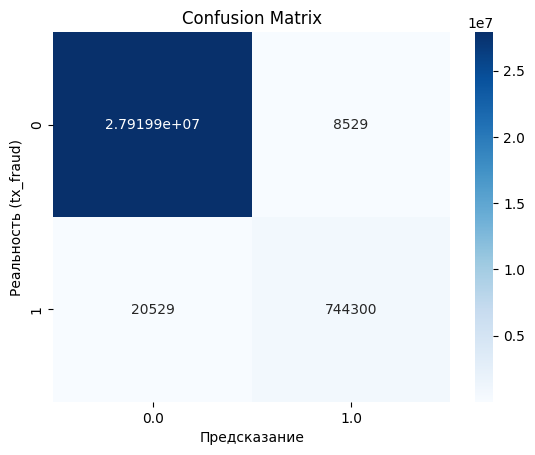

In [26]:
conf_matrix = predictions.groupBy("tx_fraud", "prediction").count().toPandas()
matrix_df = conf_matrix.pivot(index='tx_fraud', columns='prediction', values='count').fillna(0)

sns.heatmap(matrix_df, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Предсказание')
plt.ylabel('Реальность (tx_fraud)')
plt.title('Confusion Matrix')
plt.show()

In [27]:
predictions = model.transform(test)

In [28]:
get_metrics(predictions)

[Stage 1452:====================================================> (33 + 1) / 34]

Precision: 0.4440
Recall: 0.9252
F1-Score: 0.6000
FP-by-week: 74126.03


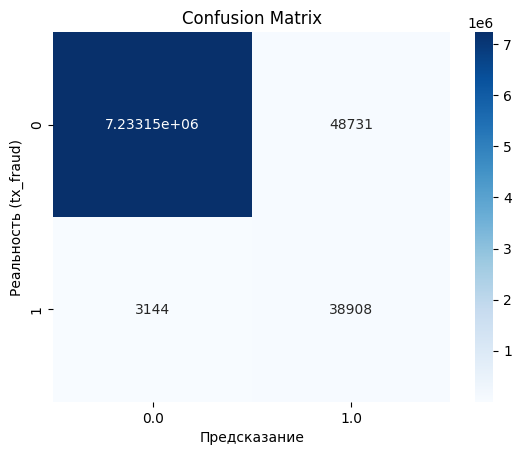

In [29]:
conf_matrix = predictions.groupBy("tx_fraud", "prediction").count().toPandas()
matrix_df = conf_matrix.pivot(index='tx_fraud', columns='prediction', values='count').fillna(0)

sns.heatmap(matrix_df, annot=True, fmt='g', cmap='Blues')
plt.xlabel('Предсказание')
plt.ylabel('Реальность (tx_fraud)')
plt.title('Confusion Matrix')
plt.show()

In [26]:
# 1. Пропускаем одну строку через модель, чтобы Spark сформировал метаданные признаков
transformed_df = model.transform(train.limit(1))

# 2. Достаем метаданные колонки "features" (которую создал VectorAssembler)
# В них Spark записывает реальные имена всех колонок внутри вектора
field_metadata = transformed_df.schema["features"].metadata

# 3. Извлекаем список атрибутов (столбцов внутри вектора)
# 'ml_attr' -> 'attrs' -> ['numeric', 'nominal', 'binary']
ml_attr = field_metadata.get("ml_attr", {})
attrs = ml_attr.get("attrs", {})

# Собираем все типы признаков в один список
all_features_list = []
for attr_type in attrs: # Проходим по 'numeric', 'nominal' и т.д.
    all_features_list.extend(attrs[attr_type])

# 4. Сортируем по индексу (idx), чтобы порядок совпал с вектором важности GBT
full_feature_names = [f["name"] for f in sorted(all_features_list, key=lambda x: x["idx"])]

# 5. Сопоставляем с важностью из последней стадии пайплайна (GBT)
importances = model.stages[-1].featureImportances.toArray()

import pandas as pd
feat_importance = pd.DataFrame({
    'feature': full_feature_names, 
    'importance': importances
})

# Выводим ТОП-20 самых влиятельных признаков
print(feat_importance.sort_values('importance', ascending=False).head(20))

                                        feature  importance
30            fraud_tx_fraud_risk_1d_full_delay    0.535639
31              fraud_tx_fraud_cn_4d_full_delay    0.063920
22                   term_tx_amount_avg_7d_hist    0.057491
21                    term_tx_amount_cn_7d_hist    0.056158
26  term_tx_amount_isnew_ct_7d_hist_sum_7d_full    0.042294
20                   term_tx_amount_std_7d_hist    0.035347
41                                      day_cos    0.029305
27  term_tx_amount_isnew_ct_7d_hist_sum_1d_full    0.025969
15                   term_tx_amount_avg_7d_full    0.021360
29              fraud_tx_fraud_cn_1d_full_delay    0.016380
14                    term_tx_amount_cn_7d_full    0.015276
40                                      day_sin    0.014791
23                   term_tx_amount_std_1d_hist    0.014162
43             ratio_term_tx_amount_avg_1d_hist    0.009513
44             ratio_term_tx_amount_std_7d_hist    0.009425
0                                     tx